this notebook contains all steps from data cleaning to eda to graphs and the model training and evaluation for the automated bidding model for used car auctions

here firstly we'll train a ml model to predict the selling price or the final hammer price of a used car from its features alone 

importing necessary libraries as for now n loading others in snippet whenever necessaryy

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb

plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


loading the dataset using pandas n then inspecting some rows n cols for the dataset

In [83]:
df = pd.read_csv('car_auction_train.csv')
print(df.tail(5))
print(df.columns)

        year    make              model   trim   body transmission state  \
447043  2014  Nissan             Altima  2.5 S  Sedan    automatic    ca   
447044  2008     Kia            Spectra     EX  Sedan    automatic    oh   
447045  2011    MINI  Cooper Countryman      S  Wagon    automatic    tn   
447046  2014     GMC       Savana Cargo   2500    Van    automatic    pa   
447047  2013     Kia               Soul   Base  Wagon    automatic    nj   

        condition  odometer  color interior  sellingprice  
447043        1.0   25056.0   gray    black         12100  
447044        2.5  218859.0  white      tan          1500  
447045        4.4   54113.0  white    black         16800  
447046        4.2    6049.0  white     gray         23800  
447047        5.0   20484.0   gray    black         11600  
Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice'],
      dtype='object')


finding out the no of null values present and the corresponding datatypes associated with each col to make sure to segrate the datatypes properly

In [84]:
print(df.isnull().mean() * 100)
print(df.dtypes)

year             0.000000
make             1.853716
model            1.872730
trim             1.917020
body             2.369544
transmission    11.698744
state            0.000000
condition        2.110959
odometer         0.015435
color            4.554544
interior         3.166327
sellingprice     0.000000
dtype: float64
year              int64
make             object
model            object
trim             object
body             object
transmission     object
state            object
condition       float64
odometer        float64
color            object
interior         object
sellingprice      int64
dtype: object


okay so handling missing values; if selling price is missing well drop it coz we cannot secondguess n train model on that, as for numerical features we can do with median, for categorial unknown or mode

In [85]:
#drop rows where the target variable is missing
df.dropna(subset=['sellingprice'], inplace=True)

#impute missing numericals with median
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df['condition'] = df['condition'].fillna(df['condition'].median())

#impute missing categoricals with 'Unknown'
cols_to_fill = ['trim', 'color', 'interior']
df[cols_to_fill] = df[cols_to_fill].fillna('Unknown')
print(df.isnull().mean() * 100)

year             0.000000
make             1.853716
model            1.872730
trim             0.000000
body             2.369544
transmission    11.698744
state            0.000000
condition        0.000000
odometer         0.000000
color            0.000000
interior         0.000000
sellingprice     0.000000
dtype: float64


outlier detection; firstly checking on the prices n range how these vary

In [86]:
print(df['sellingprice'].head(10))
print(df['sellingprice'].nlargest(10))
print(df['sellingprice'].nsmallest(10))

0    10100
1    10300
2     3300
3      600
4    21100
5    13800
6     9000
7      900
8    10800
9    22200
Name: sellingprice, dtype: int64
346410    230000
246394    183000
274353    171500
296041    169500
354940    169000
106318    167000
397434    165000
376960    161000
155935    159000
41877     158000
Name: sellingprice, dtype: int64
52457       1
96719       1
135583      1
352496      1
35577     100
83579     100
104318    100
148670    100
180174    100
185131    100
Name: sellingprice, dtype: int64


using 1st n 99th percent cutoff; here 90% of cars r b/n 5k to 25k but some has even 200k+, so using percetiles was the best optn 

In [87]:
#handling outliers using Quantile Method (1st and 99th percentiles)
lower_bound = df['sellingprice'].quantile(0.01)
upper_bound = df['sellingprice'].quantile(0.99)

#filtering the dataframe
df = df[(df['sellingprice'] >= lower_bound) & (df['sellingprice'] <= upper_bound)]

print(f"Selling price bounded between ${lower_bound:.2f} and ${upper_bound:.2f}")
print(f"Unique models before: {df['model'].nunique()}")


Selling price bounded between $500.00 and $45000.00
Unique models before: 902


In [88]:
# See what percentage of your data the top 50 models actually cover
top_50_count = df['model'].value_counts().nlargest(50).sum()
total_count = len(df)
coverage = (top_50_count / total_count) * 100

print(f"Top 50 models cover {coverage:.2f}% of the data")

Top 50 models cover 55.58% of the data


In [89]:
# Get the cumulative percentage of each model
cumulative_percent = df['model'].value_counts(normalize=True).cumsum()

# Set your target coverage (e.g., 90%)
target_coverage = 0.90

# Count how many models it takes to hit that target
n_to_keep = (cumulative_percent < target_coverage).sum() + 1

print(f"To cover {target_coverage*100}% of the data, you need the top {n_to_keep} models.")

# Then you can apply it just like before:
top_models = df['model'].value_counts().nlargest(n_to_keep).index
df['model'] = df['model'].apply(lambda x: x if x in top_models else 'Other')

To cover 90.0% of the data, you need the top 211 models.


lumping others coz 

In [90]:
# NEW CODE: Convert to Pandas category type
df['model'] = df['model'].astype('category')

print(f"Unique models after: {df['model'].nunique()}")

Unique models after: 212


NOW EDA

1]evaluating how depreciation behaves across body types across years

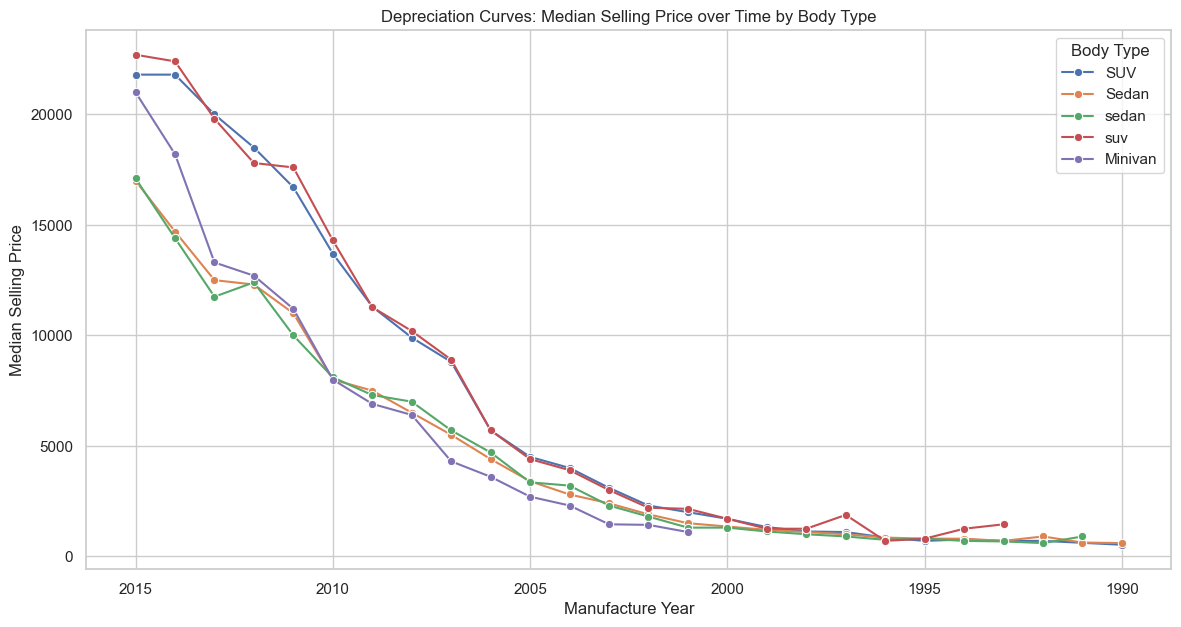

In [91]:
#identifying the top 5 most common body types
top_bodies = df['body'].value_counts().nlargest(5).index

#filtering dataset
df_top_bodies = df[df['body'].isin(top_bodies)]

#calculating median price by year and body type
depreciation_data = df_top_bodies.groupby(['year', 'body'])['sellingprice'].median().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=depreciation_data, x='year', y='sellingprice', hue='body', marker='o')
plt.title("Depreciation Curves: Median Selling Price over Time by Body Type")
plt.xlabel("Manufacture Year")
plt.ylabel("Median Selling Price")
plt.gca().invert_xaxis() 
plt.legend(title='Body Type')
plt.show()

findings from graph above(depriciation curve)

1]vehicles mostly lose their value most rapidly in first 10 yrs(sharp,steep decline)
2]after 10-15 yrs the curve tends to flatten
3]suvs (blue n red) maintain higer median than others; minivans (purple) starts high but drops very sharply as for sedans (orange ngreen) they generally hold value slightly better than minvans over longer term.

2]identifying condtn rated thresholds where prices collapse non linearly

/var/folders/70/22s2l6cs2zjfg_rj5cfyvvjh0000gn/T/ipykernel_63200/2446903380.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


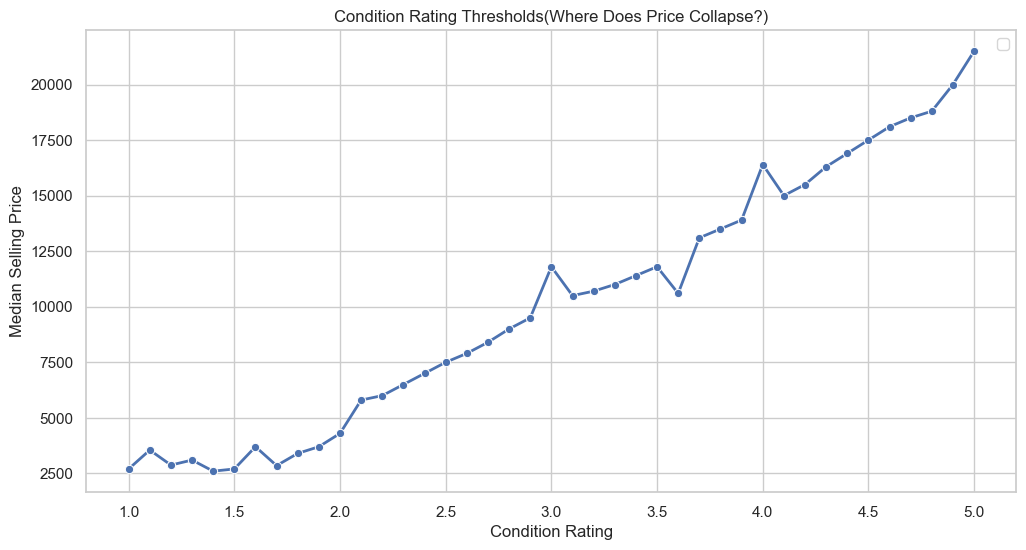

In [92]:
#calculating median price per condition rating
condition_prices = df.groupby('condition')['sellingprice'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=condition_prices, x='condition', y='sellingprice', marker='o', linewidth=2)
plt.title("Condition Rating Thresholds(Where Does Price Collapse?)")
plt.xlabel("Condition Rating")
plt.ylabel("Median Selling Price")
plt.legend()
plt.show()

for above graph(condtn rating threshold); 

1]we observe sharp spikes at whole nos 3 n 4 n immediate dropping of prices aftermath;
2]cars with score 1 to 2 r likely broken/sold for scrap coz theyr not really drivable n thus prices stay very low
3]for score=2; the price jumps meaning these cars r runnable 
4]for score=3 & 4 the price is more than score=3.1 & 4.1 coz when serached for rating x n above the one with rating x ie here score 3/4 tends to appear on more side; thus increasing their price
5]score 4.5 to 5 is the kinda perfect n as score touches 5; massive spike in price showing buysers willing to pay massive premium for used car

3]odometer to year ratio against single features


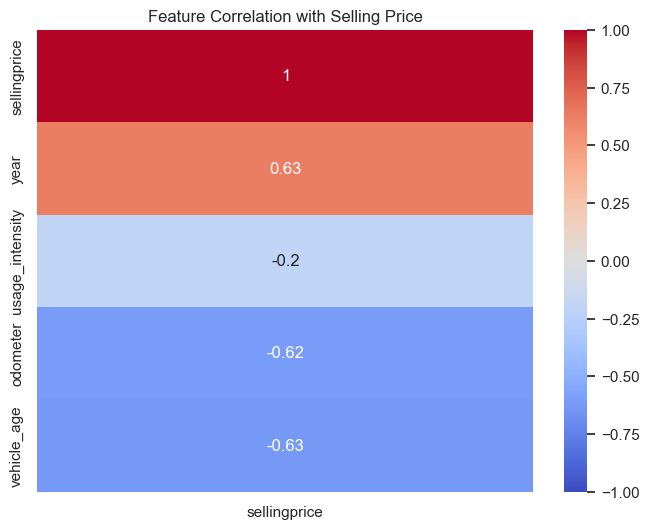

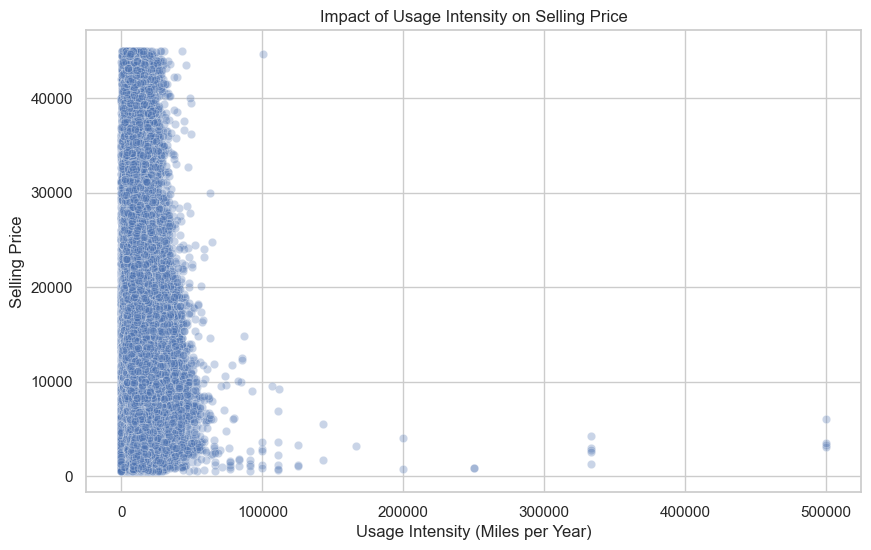

In [93]:
#calculating vehicle age 
#(assuming the max year in the dataset is the current auction year)
current_year = df['year'].max()
df['vehicle_age'] = current_year - df['year'] + 1 
# +1 to avoid division by zero for brand new cars

#creating usage intensity feature
df['usage_intensity'] = df['odometer'] / df['vehicle_age']

#plot correlation of single features vs engineered feature against selling price
cols_to_compare = ['odometer', 'year', 'vehicle_age', 'usage_intensity', 'sellingprice']
corr_matrix = df[cols_to_compare].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['sellingprice']].sort_values(by='sellingprice', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation with Selling Price")
plt.show()

#Scatter plot showing usage intensity impact
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='usage_intensity', y='sellingprice', alpha=0.3)
plt.title("Impact of Usage Intensity on Selling Price")
plt.xlabel("Usage Intensity (Miles per Year)")
plt.ylabel("Selling Price")
plt.show()

for the above heatmap of feature correlation with selling price, observations r;

1]odometer n vehicle age hv -0.62 n -0.63 showing as miles n age goes up, the price goes down
2]year has +0.63 ie newer the car, higher the price
3]usage_intensiy = -0.2 meanong the used car intensity doesnt affevt the impact overall price as much as others like milage n age do

as for the scatterplot for usage intensity on selling price;

1]majority of blue ots r squised into a thick pillar on left showing most cars r driven normal amt of miles per yr n within normal range hv sp of 45k around to 0
2]the graph has few cars supposedly driven b/n 200k to 500k miles in single yr; which almost sounds impossible n adds up as noise

4]transmission x body type synegries

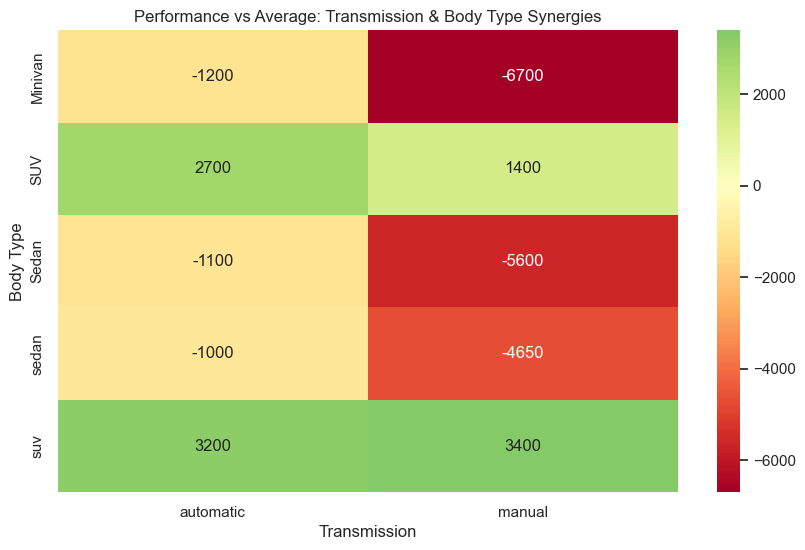

In [94]:
#calculating overall median price for baseline comparison
overall_median = df['sellingprice'].median()

#creating a pivot table of median prices
pivot_trans_body = pd.pivot_table(df_top_bodies, 
                                  values='sellingprice', 
                                  index='body', 
                                  columns='transmission', 
                                  aggfunc='median')

#calculating the difference from the overall median to see what outperforms
performance_matrix = pivot_trans_body - overall_median

plt.figure(figsize=(10, 6))
sns.heatmap(performance_matrix, annot=True, fmt=".0f", cmap='RdYlGn', center=0)
plt.title("Performance vs Average: Transmission & Body Type Synergies")
plt.xlabel("Transmission")
plt.ylabel("Body Type")
plt.show()

the above chart combines body types n transmission affecting the cars sp compared to overall avg

1]green(+ves) shows car selling more than the avg n for red(-ves) the vice versa
2]suvs r most valueable they be automatic or manual
3]minivans n sedan r least sold
4]automatic versions come on safer side for all even minvans n sedan n hold certain value above avg

5]brand value depreciation like luxury vs economic
like do luxury hold their premimum or they depriciate fatser than economy reliabke cars, which contributes as one of the imp factor in wholesale bidding

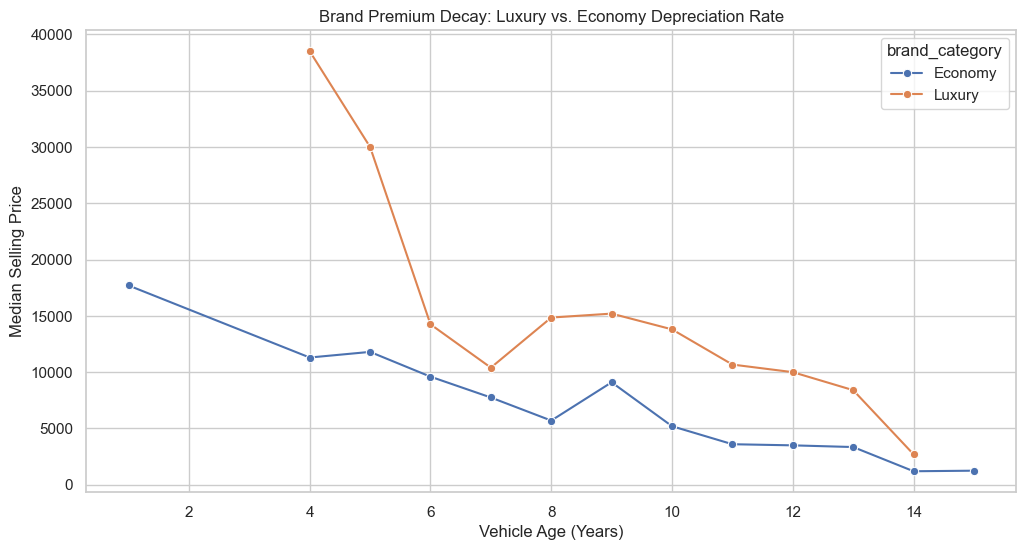

In [95]:
#list of luxury vs economy brands
luxury_brands = ['bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche', 'land rover']
economy_brands = ['toyota', 'honda', 'ford', 'chevrolet', 'nissan', 'hyundai']

#creating a new column to classify the brand type
def classify_brand(make):
    if make in luxury_brands:
        return 'Luxury'
    elif make in economy_brands:
        return 'Economy'
    else:
        return 'Other'

df['brand_category'] = df['make'].apply(classify_brand)

#filtering out 'Other' for a cleaner comparison
df_brands = df[df['brand_category'] != 'Other']

#calculating median price by vehicle age and brand category
brand_decay = df_brands.groupby(['vehicle_age', 'brand_category'])['sellingprice'].median().reset_index()

#Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=brand_decay[brand_decay['vehicle_age'] <= 15], # Look at the first 15 years
             x='vehicle_age', y='sellingprice', hue='brand_category', marker='o')
plt.title("Brand Premium Decay: Luxury vs. Economy Depreciation Rate")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Median Selling Price")
plt.show()

the plot for accounts for depriciation rate by comparing economy n luxury brands;

1]luxury(orange) starts high but a massive steep dive is over next 2-3 yrs showing luxyury cars suffer from extreme depriciation early in lifespan
2]economy(blue ones) start at much lower but. goes down at steady n gentlier pace n these dont lose massive but depriciate slowly n preticitably
3]but after certain 13 to 15 yrs these lines r almost the same n they worth the same showcasing how the brand completely vanishes over time

6]demographic factors maily geographic here by state vs body type purchased

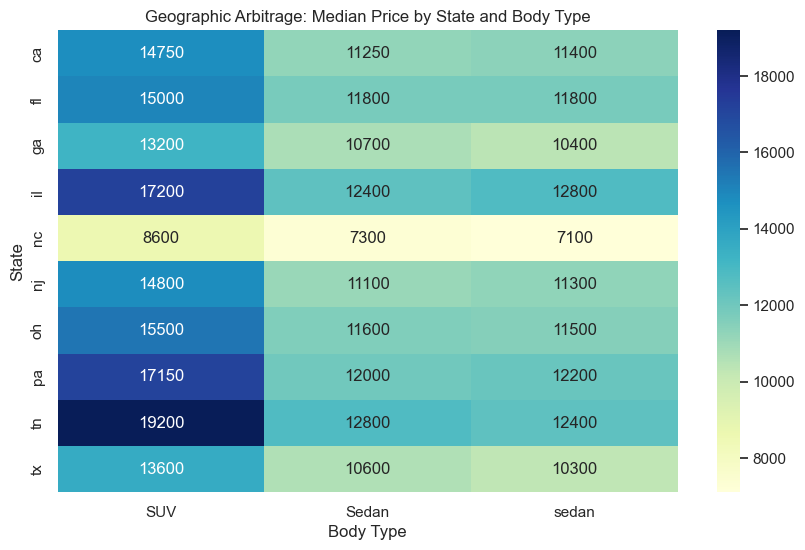

In [96]:
# Let's look at the top 3 most common body types across the top 10 most active states
top_states = df['state'].value_counts().nlargest(10).index
top_bodies = df['body'].value_counts().nlargest(3).index

df_geo = df[(df['state'].isin(top_states)) & (df['body'].isin(top_bodies))]

# Pivot to see the median price of a body type in a specific state
geo_pivot = pd.pivot_table(df_geo, 
                           values='sellingprice', 
                           index='state', 
                           columns='body', 
                           aggfunc='median')

plt.figure(figsize=(10, 6))
sns.heatmap(geo_pivot, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title("Geographic Arbitrage: Median Price by State and Body Type")
plt.xlabel("Body Type")
plt.ylabel("State")
plt.show()

the above chart visualises geographic arbitage by comparing teh median seliing price of suvs n sedans across 10 diff us states; darker blue=higher prices, lighter vice versa

1]nc=north carolina is pale yellow across board. having lower prices for both suvs(8.6k) n sedans(7k); a lot cheaper compared to other states
2]tn=tennessee has highest median price at 19.2k n pa= pennsylvania n il= illinois r very strong sellers marekt too
3]suvs r always more expensive than sedan n buysers r consistently willing to pay more for suvs regardless of geography

7]color of car natural ones vs eccentric colors demand n outlier detection 

/var/folders/70/22s2l6cs2zjfg_rj5cfyvvjh0000gn/T/ipykernel_63200/3104303985.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='color_profile', y='sellingprice', palette='Set2')


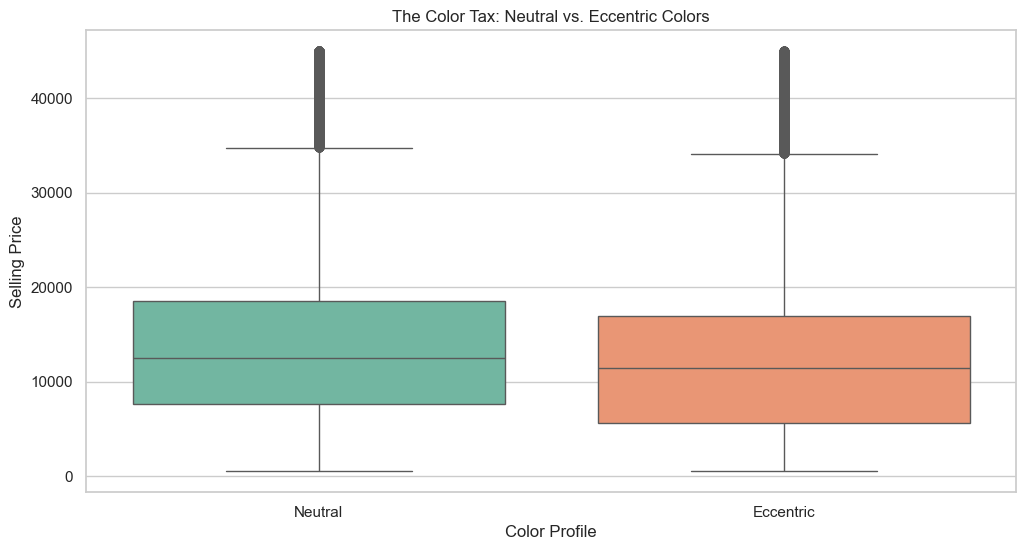

In [97]:
#Group colors into neutral vs. eccentric 
neutral_colors = ['black', 'white', 'gray', 'silver']

# Any color not in neutral is considered 'eccentric' for this quick analysis
df['color_profile'] = df['color'].apply(lambda x: 'Neutral' if x in neutral_colors else 'Eccentric')

# Plot the data (Removed the > 20 condition filter!)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='color_profile', y='sellingprice', palette='Set2')
plt.title("The Color Tax: Neutral vs. Eccentric Colors")
plt.xlabel("Color Profile")
plt.ylabel("Selling Price")
plt.show()

here in boxplot comparision in above graph; 

1]the neutral cars hv median at 12.5k n for eccentric cars(orange) at 11k
2]the neutral ones sell roughly 7.5k to 18.5k n eccentric ones roughly around 5.5k to 17k
3]the thick vertical lines of black dots from top r whiskers way past at 40k representing outliers
ie high end luxury cars still command masisve price even if painted an eccentric color like bright yellow or purple

8]trim levels vs condition for trim conventions like lx, ex, sport,le,se

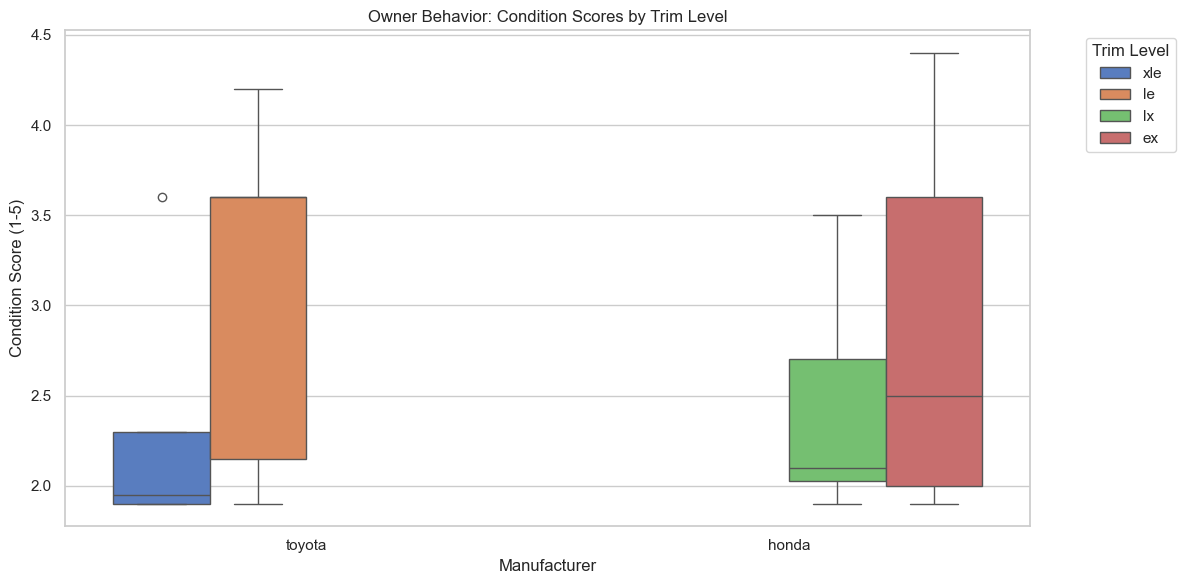

In [98]:
#defining target makes and standard commuter trims
target_makes = ['honda', 'toyota']
target_trims = ['lx', 'ex', 'sport', 'le', 'se', 'xle']

#filtering the dataset
df_trims = df[(df['make'].isin(target_makes)) & (df['trim'].isin(target_trims))]

#Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_trims, x='make', y='condition', hue='trim', palette='muted')
plt.title("Owner Behavior: Condition Scores by Trim Level")
plt.xlabel("Manufacturer")
plt.ylabel("Condition Score (1-5)")
plt.legend(title='Trim Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

the above plot compares specific trims assocaited with specific brands; toyota with xle n le trims and honda with lx n ex trims;

1]honda ex has highest median(red) at 2.5 with highest overall max score n whisker till 4.5
2]toyota xle(blue) is low n grouped n clustered b/n 1.9 and 2.3; only a small circle 3.6 as whisker noticeed
3]toyota le(orange) n honda ex(red) have large iqr range indicating massive varaition some with 4 n above while others at 2
4]green one honda lx has clustering at median score 2.1; but it doesnt drop as low as others

9]over market volatility in us states

/var/folders/70/22s2l6cs2zjfg_rj5cfyvvjh0000gn/T/ipykernel_63200/2156777640.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_median_prices, x='state', y='sellingprice', palette='viridis')


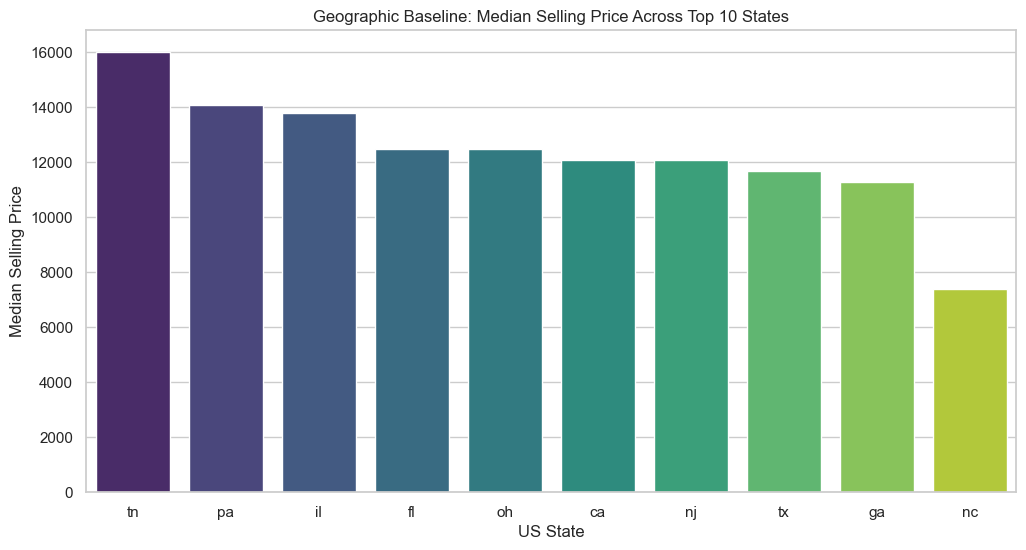

In [99]:
#identifying the top 10 highest-volume auction states
top_10_states = df['state'].value_counts().nlargest(10).index
df_states = df[df['state'].isin(top_10_states)]

#calculating the median selling price for these states and sort them
state_median_prices = df_states.groupby('state')['sellingprice'].median().reset_index()
state_median_prices = state_median_prices.sort_values(by='sellingprice', ascending=False)

#Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=state_median_prices, x='state', y='sellingprice', palette='viridis')
plt.title("Geographic Baseline: Median Selling Price Across Top 10 States")
plt.xlabel("US State")
plt.ylabel("Median Selling Price")
plt.show()

this bar plot combines the body types n rates into one overall state avg n compares:

1] tennessee(tn,purple) is priciest at median sp 16k with pennsylvania(pn) n illino(il) following behind at range around 14k
2]12k pricing is consistent along states of ohio,florida,california,new jersey n texas
3]north carolina is extreme bargain n sits at median sp at 7.3k a lot cheaper compared to other states
thus dealership n inventory building in north carolina n selling to tennessee/ pennsylvanai ayields massive baseline profit margins even before factoring in specific car models/codntion ranges


eda done; moving on to model training n hyperparamter tuning

model training n hyperparameter tuning

In [100]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

#separating features and target
X = df.drop(columns=['sellingprice'])
y = df['sellingprice']

#splitting into Train/Val sets immediately
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#defining the exact categorical columns the Arena expects
categorical_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']

#initializing the dictionary to hold our fitted encoders
encoders_dict = {}

#looping through,clean,and encode each column
for col in categorical_cols:
    le = LabelEncoder()
    
    #standardize the raw text data
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_val[col] = X_val[col].astype(str).str.lower().str.strip()
    
    #fit the encoder on the raw text words of the training set
    X_train[col] = le.fit_transform(X_train[col])
    
    #safely transform the validation data (handle unknowns by mapping them to 0)
    known_classes = set(le.classes_)
    X_val[col] = X_val[col].apply(lambda x: le.transform([x])[0] if x in known_classes else 0)
    
    #storing the actual fitted LabelEncoder object
    encoders_dict[col] = le

#exporting the dictionary of LabelEncoders to match the required submission format
joblib.dump(encoders_dict, 'encoders_Anjali_Pogulwad.pkl')
print("Success: encoders_Anjali_Pogulwad.pkl saved!")

Success: encoders_Anjali_Pogulwad.pkl saved!


encoders.pkl saved moving onto model n for model.pkl

In [ ]:
import joblib
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import randint, uniform
from sklearn.preprocessing import OrdinalEncoder # Added this import

#enforcing 11features only as such to match the submisson format
REQUIRED_FEATURES = [
    'year', 'condition', 'odometer', 'make', 'model',
    'trim', 'body', 'transmission', 'state', 'color', 'interior'
]
TARGET_COL = "sellingprice"

#Filter X to ONLY have the required 11 columns
X = df[REQUIRED_FEATURES].copy()
y = df[TARGET_COL]

#HANDLing CATEGORICAL COLUMNS
cat_cols = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']

# Cleaning the text strings just to be safe
for col in cat_cols:
    X[col] = X[col].astype(str).str.lower().str.strip()

# Using the specific OrdinalEncoder configuration
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# TRAINing VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# BASELINE MODEL
baseline_model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_val)
baseline_mae = mean_absolute_error(y_val, baseline_preds)
baseline_rmse = np.sqrt(
    mean_squared_error(y_val, baseline_preds)
)
baseline_r2 = r2_score(y_val, baseline_preds)
print("\n BASELINE MODEL :\n")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R2   : {baseline_r2:.4f}")

# HYPERPARAMETER TUNING
param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.03, 0.12),
    'max_depth': randint(3, 10),
    'num_leaves': randint(20, 80),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_samples': randint(10, 50),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2)
}

tuned_model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

cv_strategy = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=tuned_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=cv_strategy,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# TRAIN TUNED MODEL
random_search.fit(
    X_train,
    y_train
)

#BEST MODEL
best_model = random_search.best_estimator_
print("\n BEST PARAMETERS :\n")
print(random_search.best_params_)

#EVALUATE TUNED MODEL
tuned_preds = best_model.predict(X_val)
tuned_mae = mean_absolute_error(
    y_val,
    tuned_preds
)
tuned_rmse = np.sqrt(
    mean_squared_error(y_val, tuned_preds)
)
tuned_r2 = r2_score(
    y_val,
    tuned_preds
)
print("\n TUNED MODEL:\n")
print(f"MAE  : {tuned_mae:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R2   : {tuned_r2:.4f}")

#MODEL COMPARISON
print("\n MODEL COMPARISON: \n")
print("\nBaseline Model")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R2   : {baseline_r2:.4f}")
print("\nTuned Model")
print(f"MAE  : {tuned_mae:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R2   : {tuned_r2:.4f}")

#SAVE MODEL
MODEL_NAME = "Model_Anjali_Pogulwad.pkl"
joblib.dump(best_model, MODEL_NAME)
print(f"\nModel saved successfully as: {MODEL_NAME}")
# ... (Keep the rest of your script exactly the same from BASELINE MODEL downward) ...

[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 350695, number of used features: 11
[LightGBM] [Info] Start training from score 13299.076143

 BASELINE MODEL :

MAE  : 1794.1124
RMSE : 2632.2868
R2   : 0.9039
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Total Bins 961
[LightGBM] [Info] Number of data points in the train set: 233796, number of used features: 11
[LightGBM] [Info] Start training from score 13316.670593
[LightGBM] [Info] Total Bins 957
[LightGBM] [Info] Number of data points in the train set: 233797, number of used features: 11
[LightGBM] [Info] Start training from score 13299.040518
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 233797, number of used features: 11
[LightGBM] [Info] Start training from score 13281.517393
[LightGBM] [Info] Total Bins 956
[LightGBM] [Info] Number of data points in the train set: 233797, number of used features: 11
[LightGB

Baseline Model
MAE  : 1794.1124
RMSE : 2632.2868
R2   : 0.9039

Tuned Model
MAE  : 1360.8402
RMSE : 2044.5202
R2   : 0.9420

winning parameters :
learning rate =0.146 ie 406 estimators to converge
max depth = 9 and num leaves = 26; subsample = 0.984 and colsample by tree = 0.713 ie model used almost all rows for every tree but restricted cols to 71% forcing them to rely on different combinations of features

In [102]:
#LOAD MODEL AGAIN 
loaded_model = joblib.load(MODEL_NAME)
sample_preds = loaded_model.predict(X_val[:5])
print("\nSAMPLE PREDICTIONS: \n")
print(sample_preds)


SAMPLE PREDICTIONS: 

[12286.25753836 14418.8939322   3731.9562425   4382.06217158
 10689.59841786]


/var/folders/70/22s2l6cs2zjfg_rj5cfyvvjh0000gn/T/ipykernel_63200/98511101.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


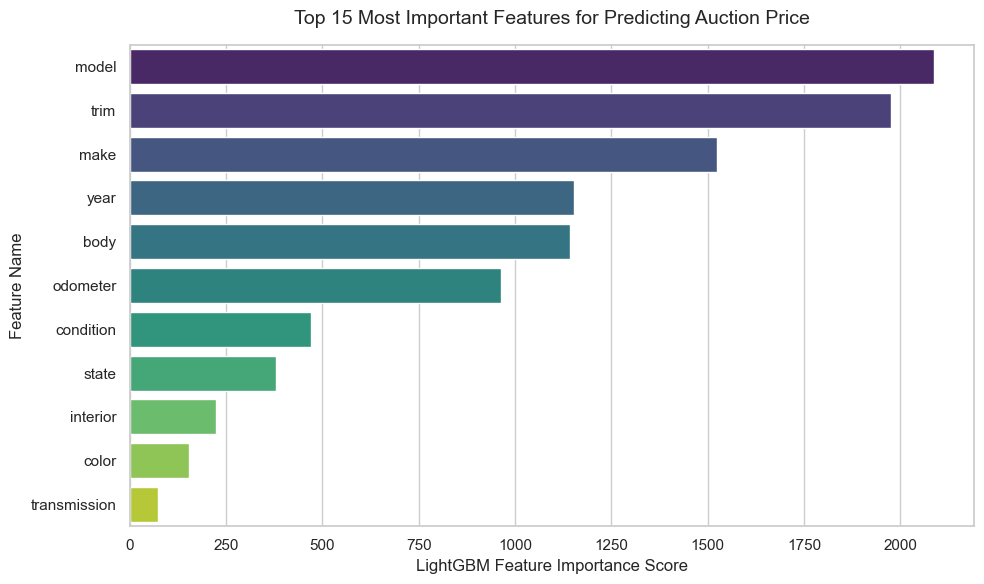

In [103]:
#FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
#Set the visual style for a professional look
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature',
    palette='viridis' 
)
plt.title('Top 15 Most Important Features for Predicting Auction Price', fontsize=14, pad=15)
plt.xlabel('LightGBM Feature Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

In [104]:
import joblib
test_encoders = joblib.load('encoders_Anjali_Pogulwad.pkl')
print(type(test_encoders))

<class 'dict'>


sanity check for actual model file

In [105]:
import joblib
import numpy as np

try:
    # 1. Load your model exactly how the Arena will
    arena_model = joblib.load('model_Anjali_Pogulwad.pkl')
    print("MODEL LOADED SUCCESSFULLY")

    # 2. Create a fake car with exactly 11 numbers 
    # (Matching the 11 features: year, condition, odometer, make, etc.)
    fake_car_features = np.array([[2015, 3.5, 50000, 15, 20, 5, 2, 1, 10, 4, 3]])

    # 3. Test a prediction
    test_prediction = arena_model.predict(fake_car_features)
    print(f"PREDICTION SUCCESS: The model predicts this car is worth ${test_prediction[0]:.2f}!")

except Exception as e:
    print(f"CRASHED: {e}")

MODEL LOADED SUCCESSFULLY
PREDICTION SUCCESS: The model predicts this car is worth $15690.38!


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
